# Model LSTM Prediksi Penjualan Eatstedi

**Dataset:** Transaksi kantin DTEDI UGM, 24 Agustus 2024 – 20 Juni 2026
**Target:** Prediksi revenue harian, mingguan, dan bulanan menggunakan Long Short-Term Memory (LSTM)

| Granularitas | Look-back | Horizon | Split | Metrik |
|---|---|---|---|---|
| Harian | 14 hari aktif | 7 hari aktif | 70/15/15 | RMSE, MAE, MAPE |
| Mingguan | 5 minggu | 4 minggu | 70/15/15 | RMSE, MAE, MAPE |
| Bulanan | 3 bulan | 3 bulan | 65/35 (no-val, data terbatas) | RMSE, MAE, MAPE |

---
## SECTION 0 — Setup & Import Libraries

In [1]:
import os, re, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Path & Directory ─────────────────────────────────────────────────────────
SQL_PATH   = os.path.join('Data', 'eatstedi-20260621-010820.sql')
DATA_DIR   = 'Data'
MODEL_DIR  = 'Models'
SCALER_DIR = os.path.join(MODEL_DIR, 'scalers')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── Hyperparameter Global ────────────────────────────────────────────────────
LOOK_BACK   = 14   # hari aktif (window input harian)
HORIZON     = 7    # hari aktif ke depan
LOOK_BACK_W = 5    # minggu — dikurangi dari 8 karena ~75 minggu aktif (val set hanya 11 minggu)
HORIZON_W   = 4    # minggu ke depan
LOOK_BACK_M = 3    # bulan — dikurangi dari 6 karena hanya ~20 bulan aktif
HORIZON_M   = 3    # bulan ke depan
BATCH_SIZE  = 32
EPOCHS      = 100

print('Setup selesai. TensorFlow:', end=' ')
import tensorflow as tf
print(tf.__version__)

Setup selesai. TensorFlow: 2.21.0


---
## SECTION 1 — Ekstraksi Data: SQL → CSV

> Parse SQL dump MariaDB secara langsung dengan Python (tanpa MySQL server). Hanya 4 tabel yang diekstrak.

### 1.1 — Fungsi Parser SQL

In [2]:
def _parse_sql_tuples(text):
    '''
    Character-level parser untuk VALUES dalam INSERT SQL.
    Mengembalikan list of tuples dari teks VALUES block.
    Menggunakan chr() untuk menghindari ambiguitas escape karakter.
    '''
    Q  = chr(39)   # single quote
    BS = chr(92)   # backslash
    NL = chr(10)   # newline
    TB = chr(9)    # tab
    CR = chr(13)   # carriage return

    rows = []
    i = 0
    n = len(text)

    while i < n:
        # Cari '(' awal tuple
        while i < n and text[i] != '(':
            i += 1
        if i >= n:
            break
        i += 1  # lewati '('

        vals = []

        while i < n and text[i] != ')':
            # Lewati whitespace antar nilai
            while i < n and text[i] in (' ', NL, TB, CR):
                i += 1
            if i >= n or text[i] == ')':
                break

            if text[i] == Q:
                # ── String value ─────────────────────────────────
                i += 1
                buf = []
                while i < n:
                    c = text[i]
                    if c == BS and i + 1 < n:
                        nc = text[i + 1]
                        i += 2
                        if   nc == Q:   buf.append(Q)
                        elif nc == 'n': buf.append(NL)
                        elif nc == 't': buf.append(TB)
                        elif nc == 'r': buf.append(CR)
                        elif nc == BS:  buf.append(BS)
                        else:           buf.append(nc)
                    elif c == Q:
                        i += 1
                        break
                    else:
                        buf.append(c)
                        i += 1
                vals.append(''.join(buf))

            elif text[i:i+4] == 'NULL':
                # ── NULL value ───────────────────────────────────
                vals.append(None)
                i += 4

            else:
                # ── Numeric / unquoted value ─────────────────────
                buf = []
                while i < n and text[i] not in (',', ')', ' ', NL, TB, CR):
                    buf.append(text[i])
                    i += 1
                vals.append(''.join(buf) if buf else None)

            # Lewati koma pemisah antar nilai
            while i < n and text[i] in (' ', NL, TB, CR):
                i += 1
            if i < n and text[i] == ',':
                i += 1

        if i < n and text[i] == ')':
            i += 1

        if vals:
            rows.append(tuple(vals))

    return rows


def parse_sql_table(sql_path, table_name):
    '''
    Stream-baca SQL dump, ekstrak INSERT block untuk table_name.
    Hemat memori karena hanya buffer baris yang relevan.
    Return: list of tuples
    '''
    lines = []
    capturing = False

    with open(sql_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            s = line.rstrip()
            if f'LOCK TABLES `{table_name}` WRITE' in s:
                capturing = True
                continue
            if capturing and 'UNLOCK TABLES' in s:
                break
            if capturing:
                skip = (
                    not s
                    or s.startswith('--')
                    or s.startswith('/*!')
                    or s.startswith('SET ')
                    or s.startswith('INSERT INTO')
                )
                if not skip:
                    lines.append(s)

    return _parse_sql_tuples(' '.join(lines))

print('Parser siap.')

Parser siap.


### 1.2 — Ekstrak Tabel dari SQL Dump

In [3]:
# Kategori di-hardcode (6 baris, icon SVG terlalu panjang untuk di-parse)
CATEGORIES = {
    1: 'MAKANAN KERING',
    2: 'MINUMAN',
    3: 'SNACKS',
    4: 'ICE CREAM',
    5: 'MAKANAN BASAH',
    6: 'MERCH',
}

RAW_CSV = os.path.join(DATA_DIR, 'raw_transactions.csv')

if os.path.exists(RAW_CSV):
    print('raw_transactions.csv sudah ada — skip parsing SQL.')
    df_raw = pd.read_csv(RAW_CSV, parse_dates=['date', 'succeeded_at'])
else:
    # ── invoices ─────────────────────────────────────────────────────────────
    print('Parsing invoices ...')
    inv_cols = ['id','user_id','payment_id','is_paid','total_price','total_quantity',
                'status','charge','customer_name','succeeded_at','created_at','updated_at']
    df_inv = pd.DataFrame(parse_sql_table(SQL_PATH, 'invoices'), columns=inv_cols)
    df_inv['is_paid']        = df_inv['is_paid'].astype(int)
    df_inv['total_price']    = df_inv['total_price'].astype(float)
    df_inv['total_quantity'] = df_inv['total_quantity'].astype(int)
    df_inv['succeeded_at']   = pd.to_datetime(df_inv['succeeded_at'])
    df_inv['id']             = df_inv['id'].astype(int)
    print(f'  → {len(df_inv):,} baris  |  lunas: {(df_inv.is_paid==1).sum():,}')

    # ── product_sold ─────────────────────────────────────────────────────────
    print('Parsing product_sold ...')
    ps_cols = ['id','invoice_id','supplier_id','product_id','quantity','price',
               'purchased_at','created_at','updated_at']
    df_ps = pd.DataFrame(parse_sql_table(SQL_PATH, 'product_sold'), columns=ps_cols)
    df_ps['invoice_id']  = df_ps['invoice_id'].astype(int)
    df_ps['product_id']  = df_ps['product_id'].astype(int)
    df_ps['quantity']    = pd.to_numeric(df_ps['quantity'], errors='coerce')
    df_ps['price']       = pd.to_numeric(df_ps['price'],    errors='coerce')
    print(f'  → {len(df_ps):,} baris')

    # ── products ─────────────────────────────────────────────────────────────
    print('Parsing products ...')
    prod_cols = ['id','supplier_id','category_id','picture','name','slug','price',
                 'created_at','updated_at']
    df_prod = pd.DataFrame(parse_sql_table(SQL_PATH, 'products'), columns=prod_cols)
    df_prod['id']          = df_prod['id'].astype(int)
    df_prod['category_id'] = df_prod['category_id'].astype(int)
    df_prod['category_name'] = df_prod['category_id'].map(CATEGORIES)
    print(f'  → {len(df_prod):,} produk')

    # ── Join & Filter ─────────────────────────────────────────────────────────
    df_paid = df_inv[df_inv['is_paid'] == 1].copy()

    df_ps_prod = df_ps.merge(
        df_prod[['id','name','category_id','category_name']],
        left_on='product_id', right_on='id', how='left', suffixes=('','_prod')
    )
    df_raw = df_ps_prod.merge(
        df_paid[['id','succeeded_at','total_price','total_quantity']],
        left_on='invoice_id', right_on='id', how='inner', suffixes=('','_inv')
    )
    df_raw['date'] = pd.to_datetime(df_raw['succeeded_at'].dt.date)
    df_raw.to_csv(RAW_CSV, index=False)
    print(f'  Saved raw_transactions.csv: {len(df_raw):,} baris')

print(df_raw.head(3))

raw_transactions.csv sudah ada — skip parsing SQL.
   id  invoice_id  supplier_id  product_id  quantity  price  \
0  70          33           15          25         4   4000   
1  71          33           15         107         1   2500   
2  72          33            6          13         2   2500   

          purchased_at           created_at           updated_at  id_prod  \
0  2024-08-26 08:14:38  2024-08-26 08:14:38  2024-08-26 08:14:38       25   
1  2024-08-26 08:14:38  2024-08-26 08:14:38  2024-08-26 08:14:38      107   
2  2024-08-26 08:14:38  2024-08-26 08:14:38  2024-08-26 08:14:38       13   

                 name  category_id  category_name  id_inv        succeeded_at  \
0  LARIST AIR MINERAL            2        MINUMAN      33 2024-08-26 08:14:38   
1              MOMOGI            3         SNACKS      33 2024-08-26 08:14:38   
2          TAHU BAKSO            5  MAKANAN BASAH      33 2024-08-26 08:14:38   

   total_price  total_quantity       date  
0      23500.0    

### 1.3 — Agregasi Harian

In [4]:
DAILY_CSV = os.path.join(DATA_DIR, 'daily_sales.csv')

if os.path.exists(DAILY_CSV):
    print('daily_sales.csv sudah ada — skip agregasi.')
    daily_sales = pd.read_csv(DAILY_CSV, parse_dates=['date'])
else:
    # Gunakan data invoices langsung (aggregate per invoice, bukan per item)
    df_paid_agg = df_raw.drop_duplicates(subset=['invoice_id'])[
        ['date','succeeded_at','total_price','total_quantity','invoice_id']
    ].copy()
    df_paid_agg = df_paid_agg.rename(columns={'invoice_id': 'inv_id'})

    daily_sales = df_paid_agg.groupby('date').agg(
        revenue=('total_price',    'sum'),
        transactions=('inv_id',    'count'),
        qty_sold=('total_quantity','sum'),
    ).reset_index()

    daily_sales['day_of_week']  = daily_sales['date'].dt.dayofweek
    daily_sales['week_of_year'] = daily_sales['date'].dt.isocalendar().week.astype(int)
    daily_sales['month']        = daily_sales['date'].dt.month
    daily_sales['year']         = daily_sales['date'].dt.year
    daily_sales['is_weekend']   = (daily_sales['day_of_week'] >= 5).astype(int)
    daily_sales['is_holiday']   = daily_sales['month'].isin([1, 7]).astype(int)
    daily_sales['is_ramadan']   = (
        ((daily_sales['year'] == 2025) & (daily_sales['month'] == 3)) |
        ((daily_sales['year'] == 2026) & (daily_sales['month'] == 3))
    ).astype(int)

    daily_sales.sort_values('date', inplace=True)
    daily_sales.to_csv(DAILY_CSV, index=False)
    print(f'Saved daily_sales.csv: {len(daily_sales)} hari')

print(f'Rentang: {daily_sales.date.min().date()} – {daily_sales.date.max().date()}')
print(f'Hari aktif: {len(daily_sales[daily_sales.revenue>0])} / {len(daily_sales)}')
daily_sales.head()

daily_sales.csv sudah ada — skip agregasi.
Rentang: 2024-08-26 – 2026-06-20
Hari aktif: 313 / 313


,date,revenue,transactions,qty_sold,day_of_week,week_of_year,month,year,is_weekend,is_holiday,is_ramadan
0,2024-08-26,1701500.0,113,585,0,35,8,2024,0,0,0
1,2024-08-27,1746500.0,245,611,1,35,8,2024,0,0,0
2,2024-08-28,1650500.0,179,570,2,35,8,2024,0,0,0
3,2024-08-29,1814500.0,219,646,3,35,8,2024,0,0,0
4,2024-08-30,1233500.0,167,453,4,35,8,2024,0,0,0


### 1.4 — Agregasi Mingguan & Bulanan

In [5]:
WEEKLY_CSV  = os.path.join(DATA_DIR, 'weekly_sales.csv')
MONTHLY_CSV = os.path.join(DATA_DIR, 'monthly_sales.csv')

df_d = pd.read_csv(DAILY_CSV, parse_dates=['date'])

# ── Weekly ───────────────────────────────────────────────────────────────────
if not os.path.exists(WEEKLY_CSV):
    weekly_sales = df_d.groupby(['year','week_of_year']).agg(
        revenue=('revenue',       'sum'),
        transactions=('transactions', 'sum'),
        qty_sold=('qty_sold',      'sum'),
        active_days=('date',       'count'),
        week_start=('date',        'min'),
    ).reset_index()
    weekly_sales['year_week'] = (
        weekly_sales['year'].astype(str) + '-W' +
        weekly_sales['week_of_year'].astype(str).str.zfill(2)
    )
    weekly_sales.sort_values('week_start', inplace=True)
    weekly_sales.to_csv(WEEKLY_CSV, index=False)
    print(f'Saved weekly_sales.csv: {len(weekly_sales)} minggu')
else:
    print('weekly_sales.csv sudah ada.')

# ── Monthly ───────────────────────────────────────────────────────────────────
if not os.path.exists(MONTHLY_CSV):
    monthly_sales = df_d.groupby(['year','month']).agg(
        revenue=('revenue',       'sum'),
        transactions=('transactions', 'sum'),
        qty_sold=('qty_sold',      'sum'),
        active_days=('date',       'count'),
    ).reset_index()
    monthly_sales['year_month'] = (
        monthly_sales['year'].astype(str) + '-' +
        monthly_sales['month'].astype(str).str.zfill(2)
    )
    monthly_sales.sort_values(['year','month'], inplace=True)
    monthly_sales.to_csv(MONTHLY_CSV, index=False)
    print(f'Saved monthly_sales.csv: {len(monthly_sales)} bulan')
else:
    print('monthly_sales.csv sudah ada.')

monthly = pd.read_csv(MONTHLY_CSV)
print(monthly[['year_month','revenue','active_days']].to_string(index=False))

weekly_sales.csv sudah ada.
monthly_sales.csv sudah ada.
year_month    revenue  active_days
   2024-08  8146500.0            5
   2024-09 28222500.0           20
   2024-10 21755500.0           20
   2024-11 35490500.0           20
   2024-12  5841500.0            8
   2025-02 24284000.0           16
   2025-03  1358500.0           15
   2025-04 21033500.0           16
   2025-05 36210000.0           17
   2025-06 16750500.0           13
   2025-07     3500.0            1
   2025-08 17068500.0           10
   2025-09 40921994.0           18
   2025-10 42182000.0           23
   2025-11 38036000.0           20
   2025-12 15118000.0           15
   2026-02  8904000.0           13
   2026-03  3410000.0           12
   2026-04 38595000.0           21
   2026-05 43247000.0           16
   2026-06 24621500.0           14


---
## SECTION 2 — Exploratory Data Analysis (EDA)

### 2.1 — Time Series Revenue Harian

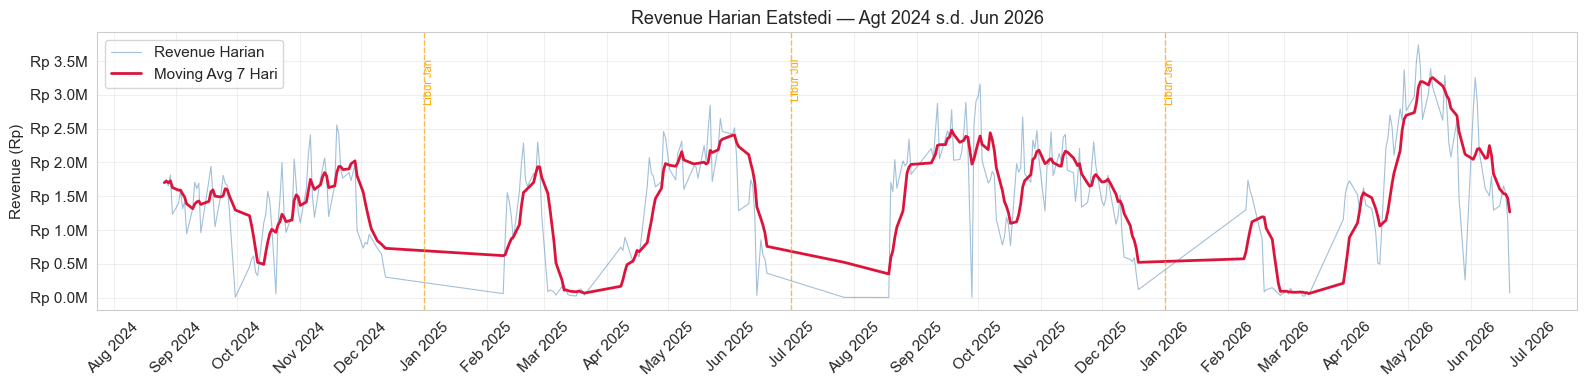

Total hari aktif  : 313
Revenue total     : Rp 471,200,494
Revenue rata-rata : Rp 1,505,433/hari aktif
Revenue tertinggi : Rp 3,738,500  (2026-05-06)


In [6]:
df = pd.read_csv(DAILY_CSV, parse_dates=['date'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['date'], df['revenue'], alpha=0.5, linewidth=0.8,
        color='steelblue', label='Revenue Harian')
ax.plot(df['date'], df['revenue'].rolling(7, min_periods=1).mean(),
        color='crimson', linewidth=2, label='Moving Avg 7 Hari')

# Anotasi libur
for yr in [2025, 2026]:
    for mo, label in [(1,'Libur Jan'), (7,'Libur Jul')]:
        d = pd.Timestamp(yr, mo, 1)
        if df['date'].min() <= d <= df['date'].max():
            ax.axvline(d, color='orange', linestyle='--', alpha=0.7, linewidth=1)
            ax.text(d, ax.get_ylim()[1]*0.9, label, fontsize=8, color='orange', rotation=90, va='top')

ax.set_title('Revenue Harian Eatstedi — Agt 2024 s.d. Jun 2026', fontsize=13)
ax.set_ylabel('Revenue (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total hari aktif  : {len(df[df.revenue>0])}")
print(f"Revenue total     : Rp {df['revenue'].sum():,.0f}")
print(f"Revenue rata-rata : Rp {df[df.revenue>0]['revenue'].mean():,.0f}/hari aktif")
print(f"Revenue tertinggi : Rp {df['revenue'].max():,.0f}  ({df.loc[df.revenue.idxmax(),'date'].date()})")

### 2.2 — Pola Bulanan & Hari Aktif

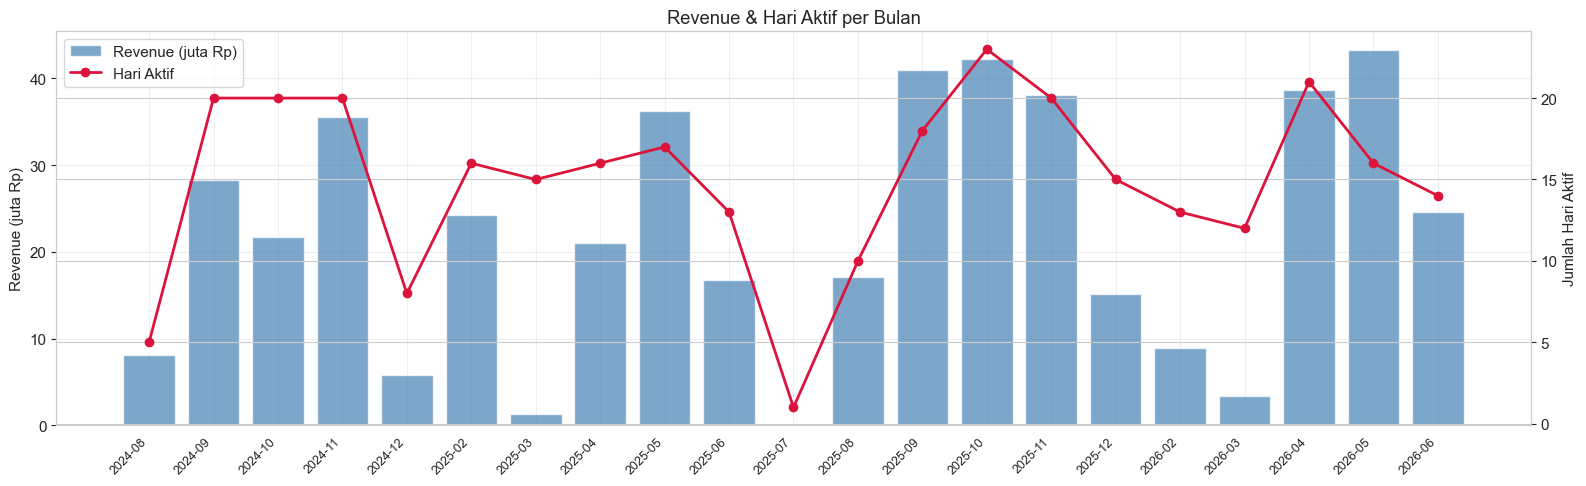

In [7]:
monthly = pd.read_csv(MONTHLY_CSV)
monthly_all = monthly.copy()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

x = range(len(monthly_all))
bars = ax1.bar(x, monthly_all['revenue']/1e6, color='steelblue', alpha=0.7, label='Revenue (juta Rp)')
ax2.plot(x, monthly_all['active_days'], 'o-', color='crimson',
         linewidth=2, markersize=6, label='Hari Aktif')

ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_all['year_month'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Revenue (juta Rp)')
ax2.set_ylabel('Jumlah Hari Aktif')
ax1.set_title('Revenue & Hari Aktif per Bulan')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 — Heatmap Pola Mingguan × Bulan

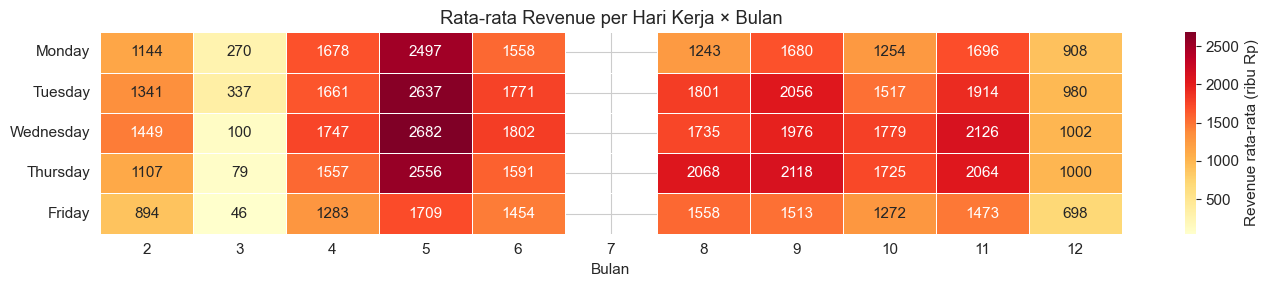

In [8]:
df['day_name'] = df['date'].dt.day_name()
df_active_eda  = df[df['revenue'] > 0].copy()

pivot = df_active_eda.pivot_table(
    values='revenue', index='day_name', columns='month', aggfunc='mean'
)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    pivot / 1000, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Revenue rata-rata (ribu Rp)'},
    linewidths=0.5
)
ax.set_title('Rata-rata Revenue per Hari Kerja × Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 2.4 — Distribusi & Korelasi

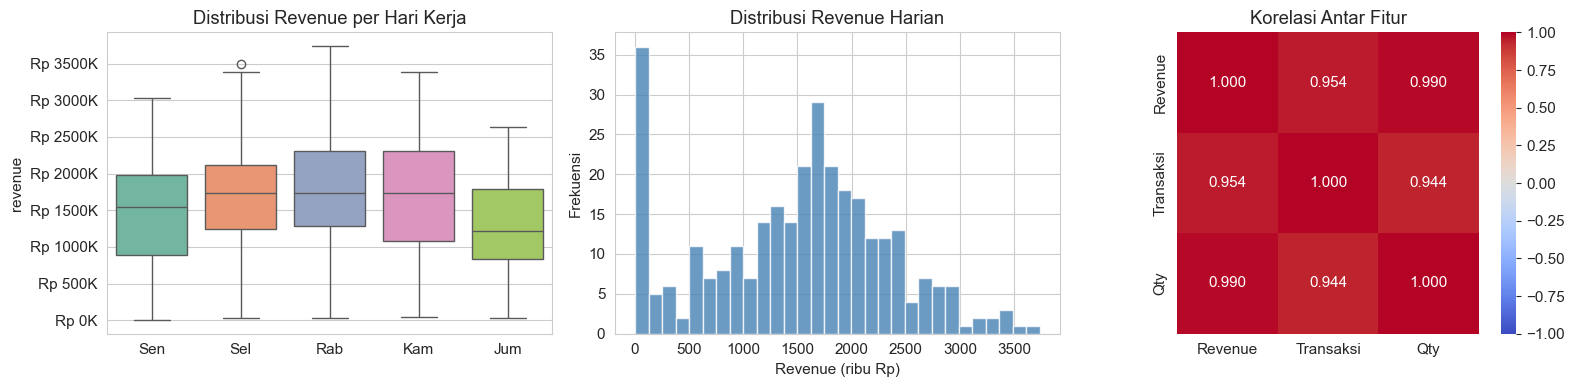

Outlier (IQR): 0 hari
Empty DataFrame
Columns: [date, revenue, day_of_week, month]
Index: []


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Box plot per hari
ax = axes[0]
day_map = {0:'Sen',1:'Sel',2:'Rab',3:'Kam',4:'Jum'}
df_wd = df_active_eda.copy()
df_wd['hari'] = df_wd['day_of_week'].map(day_map)
sns.boxplot(data=df_wd, x='hari', y='revenue', order=['Sen','Sel','Rab','Kam','Jum'],
            ax=ax, palette='Set2')
ax.set_title('Distribusi Revenue per Hari Kerja')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e3:.0f}K'))
ax.set_xlabel('')

# Histogram revenue
ax = axes[1]
ax.hist(df_active_eda['revenue']/1000, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribusi Revenue Harian')
ax.set_xlabel('Revenue (ribu Rp)')
ax.set_ylabel('Frekuensi')

# Korelasi
ax = axes[2]
corr = df_active_eda[['revenue','transactions','qty_sold']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            vmin=-1, vmax=1, square=True,
            xticklabels=['Revenue','Transaksi','Qty'],
            yticklabels=['Revenue','Transaksi','Qty'])
ax.set_title('Korelasi Antar Fitur')

plt.tight_layout()
plt.show()

# Outlier report
Q1, Q3 = df_active_eda['revenue'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_active_eda[df_active_eda['revenue'] > Q3 + 1.5 * IQR]
print(f'Outlier (IQR): {len(outliers)} hari')
print(outliers[['date','revenue','day_of_week','month']].to_string(index=False))

---
## SECTION 3 — Preprocessing & Feature Engineering

In [10]:
df = pd.read_csv(DAILY_CSV, parse_dates=['date'])

# Hanya hari aktif bisnis (revenue > 0)
df_active = df[df['revenue'] > 0].copy().reset_index(drop=True)
print(f'Hari aktif: {len(df_active)} dari {len(df)} hari total')

# ── Cyclical encoding ─────────────────────────────────────────────────────────
df_active['week_sin'] = np.sin(2 * np.pi * df_active['week_of_year'] / 52)
df_active['week_cos'] = np.cos(2 * np.pi * df_active['week_of_year'] / 52)
df_active['month_sin'] = np.sin(2 * np.pi * df_active['month'] / 12)
df_active['month_cos'] = np.cos(2 * np.pi * df_active['month'] / 12)
df_active['dow_sin'] = np.sin(2 * np.pi * df_active['day_of_week'] / 5)
df_active['dow_cos'] = np.cos(2 * np.pi * df_active['day_of_week'] / 5)

# ── Fitur input LSTM ──────────────────────────────────────────────────────────
FEATURES = [
    'revenue', 'transactions', 'qty_sold',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'dow_sin', 'dow_cos', 'is_ramadan'
]
N_FEATURES = len(FEATURES)
print(f'Jumlah fitur  : {N_FEATURES}')
print(f'Fitur         : {FEATURES}')

# ── Train / Validation / Test split (chronological) ──────────────────────────
n = len(df_active)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

df_train = df_active.iloc[:n_train]
df_val   = df_active.iloc[n_train : n_train + n_val]
df_test  = df_active.iloc[n_train + n_val:]

print(f'\nTrain : {len(df_train)} hari  ({df_train.date.min().date()} – {df_train.date.max().date()})')
print(f'Val   : {len(df_val)} hari  ({df_val.date.min().date()}   – {df_val.date.max().date()})')
print(f'Test  : {len(df_test)} hari  ({df_test.date.min().date()}   – {df_test.date.max().date()})')

Hari aktif: 313 dari 313 hari total
Jumlah fitur  : 10
Fitur         : ['revenue', 'transactions', 'qty_sold', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_ramadan']

Train : 219 hari  (2024-08-26 – 2025-11-25)
Val   : 46 hari  (2025-11-26   – 2026-04-06)
Test  : 48 hari  (2026-04-07   – 2026-06-20)


In [11]:
# ── MinMaxScaler — fit HANYA pada train ──────────────────────────────────────
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train[FEATURES].values)
val_scaled   = scaler.transform(df_val[FEATURES].values)
test_scaled  = scaler.transform(df_test[FEATURES].values)

# Scaler khusus revenue untuk inverse_transform evaluasi
scaler_rev = MinMaxScaler()
scaler_rev.fit(df_train[['revenue']].values)

with open(os.path.join(SCALER_DIR, 'scaler_daily.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(SCALER_DIR, 'scaler_revenue.pkl'), 'wb') as f:
    pickle.dump(scaler_rev, f)

print('Scaler tersimpan.')
print(f'Shape: train={train_scaled.shape}, val={val_scaled.shape}, test={test_scaled.shape}')

Scaler tersimpan.
Shape: train=(219, 10), val=(46, 10), test=(48, 10)


---
## SECTION 4 — Pembentukan Sequence LSTM & Split

In [12]:
def create_sequences(data, look_back, horizon, target_col=0):
    '''
    Membentuk input-output sequence untuk LSTM.
    data       : array (n_samples, n_features)
    look_back  : panjang window input
    horizon    : panjang prediksi ke depan
    target_col : indeks kolom yang diprediksi (0 = revenue)
    Returns    : X (samples, look_back, n_features), y (samples, horizon)
    '''
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back : i + look_back + horizon, target_col])
    return np.array(X), np.array(y)


# ── Sequence harian ───────────────────────────────────────────────────────────
X_train, y_train = create_sequences(train_scaled, LOOK_BACK, HORIZON)
X_val,   y_val   = create_sequences(val_scaled,   LOOK_BACK, HORIZON)
X_test,  y_test  = create_sequences(test_scaled,  LOOK_BACK, HORIZON)

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}     y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print(f'\nTotal training samples : {len(X_train)}')
print(f'Jumlah fitur per timestep : {X_train.shape[2]}')

X_train : (199, 14, 10)   y_train : (199, 7)
X_val   : (26, 14, 10)     y_val   : (26, 7)
X_test  : (28, 14, 10)    y_test  : (28, 7)

Total training samples : 199
Jumlah fitur per timestep : 10


---
## SECTION 5 — Arsitektur & Training Model

### 5.1 — Builder Fungsi & Callbacks

In [13]:
def build_lstm_model(look_back, n_features, horizon, units=64, dropout=0.2):
    '''Stacked 2-layer LSTM dengan Dropout dan regularisasi L2.'''
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(look_back, n_features),
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False,
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(horizon)
    ], name=f'lstm_{look_back}lb_{horizon}h')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=7, min_lr=1e-6, verbose=1),
]

print('Builder siap.')

Builder siap.


### 5.2 — Training Model Harian

In [14]:
model_daily = build_lstm_model(LOOK_BACK, N_FEATURES, HORIZON)
model_daily.summary()

Model: "lstm_14lb_7h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,903 (128.53 KB)

 Trainable params: 32,903 (128.53 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model_daily.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS,
    verbose=1
)
model_daily.save(os.path.join(MODEL_DIR, 'lstm_daily.keras'))
print('\nModel harian tersimpan.')

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.2476 - mae: 0.4226 - val_loss: 0.0647 - val_mae: 0.1939 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1397 - mae: 0.3016 - val_loss: 0.1430 - val_mae: 0.3237 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0999 - mae: 0.2457 - val_loss: 0.1247 - val_mae: 0.2987 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0889 - mae: 0.2285 - val_loss: 0.1110 - val_mae: 0.2831 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0782 - mae: 0.2121 - val_loss: 0.1036 - val_mae: 0.2768 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0761 - mae: 0.2088 - val_loss: 0.0867 - val_mae: 0.2533 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0730 - mae: 0.2061 - val_loss: 0.0779 - val_mae: 0.2409 - learning_rate: 0.0010
Epoch 8/100
1/7 ━━━━

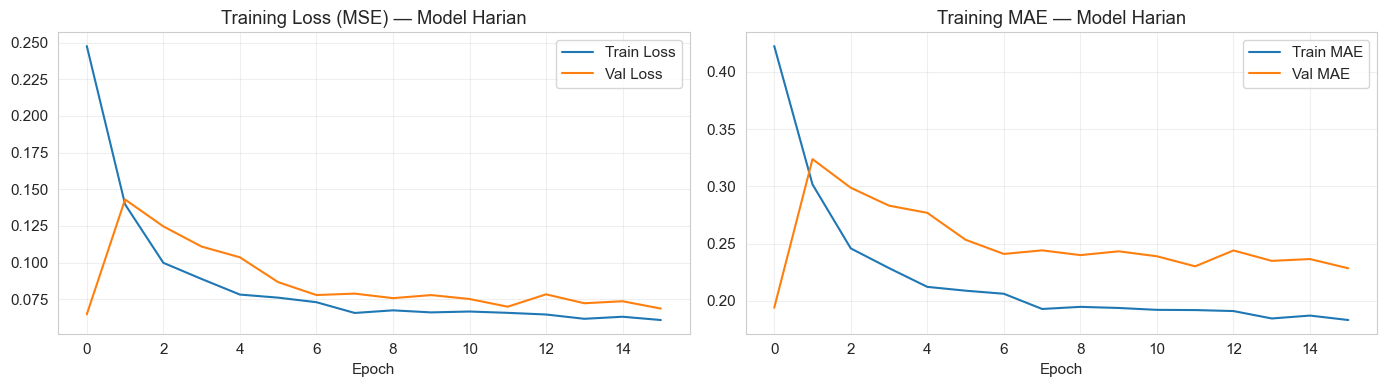

Best epoch: 1


In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training Loss (MSE) — Model Harian')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Training MAE — Model Harian')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best epoch: {np.argmin(history.history["val_loss"]) + 1}')

### 5.3 — Training Model Mingguan

In [17]:
weekly = pd.read_csv(WEEKLY_CSV, parse_dates=['week_start'])
weekly = weekly[weekly['revenue'] > 0].sort_values('week_start').reset_index(drop=True)

FEATURES_W = ['revenue', 'transactions', 'qty_sold', 'active_days']
N_FEATURES_W = len(FEATURES_W)

n_w       = len(weekly)
n_train_w = int(n_w * 0.70)
n_val_w   = int(n_w * 0.15)

scaler_w = MinMaxScaler()
train_w  = scaler_w.fit_transform(weekly.iloc[:n_train_w][FEATURES_W].values)
val_w    = scaler_w.transform(weekly.iloc[n_train_w:n_train_w+n_val_w][FEATURES_W].values)
test_w   = scaler_w.transform(weekly.iloc[n_train_w+n_val_w:][FEATURES_W].values)

with open(os.path.join(SCALER_DIR, 'scaler_weekly.pkl'), 'wb') as f:
    pickle.dump(scaler_w, f)

X_train_w, y_train_w = create_sequences(train_w, LOOK_BACK_W, HORIZON_W)
X_val_w,   y_val_w   = create_sequences(val_w,   LOOK_BACK_W, HORIZON_W)
X_test_w,  y_test_w  = create_sequences(test_w,  LOOK_BACK_W, HORIZON_W)

print(f'Weekly — train: {len(weekly.iloc[:n_train_w])} minggu, '
      f'val: {n_val_w} minggu, test: {n_w - n_train_w - n_val_w} minggu')
print(f'X_train_w: {X_train_w.shape}')

model_weekly = build_lstm_model(LOOK_BACK_W, N_FEATURES_W, HORIZON_W, units=32)
history_w = model_weekly.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=16,
    validation_data=(X_val_w, y_val_w),
    callbacks=CALLBACKS,
    verbose=1
)
model_weekly.save(os.path.join(MODEL_DIR, 'lstm_weekly.keras'))
print('Model mingguan tersimpan.')

Weekly — train: 48 minggu, val: 10 minggu, test: 11 minggu
X_train_w: (40, 5, 4)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - loss: 0.3314 - mae: 0.4991 - val_loss: 0.0294 - val_mae: 0.0770 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3035 - mae: 0.4738 - val_loss: 0.0292 - val_mae: 0.0860 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2819 - mae: 0.4540 - val_loss: 0.0315 - val_mae: 0.1084 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2553 - mae: 0.4319 - val_loss: 0.0365 - val_mae: 0.1329 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2389 - mae: 0.4147 - val_loss: 0.0449 - val_mae: 0.1592 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2160 - mae: 0.3932 - val_loss: 0.0584 - val_mae: 0.1906 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1905 - mae: 0.3708

### 5.4 — Training Model Bulanan

In [18]:
monthly = pd.read_csv(MONTHLY_CSV)
monthly = monthly[monthly['revenue'] > 0].sort_values(['year','month']).reset_index(drop=True)

FEATURES_M   = ['revenue', 'transactions', 'qty_sold', 'active_days']
N_FEATURES_M = len(FEATURES_M)

n_m = len(monthly)
# Data bulanan sangat terbatas (~20 bulan). Rumus minimum sampel:
#   test harus >= LOOK_BACK_M + HORIZON_M bulan agar ada minimal 1 sequence.
# Gunakan split 65/35 train/test TANPA val set untuk menghindari array kosong.
n_test_m  = LOOK_BACK_M + HORIZON_M + 2   # margin 2 bulan → minimal 3 test sequences
n_train_m = n_m - n_test_m
n_val_m   = 0  # tidak ada val set untuk data bulanan

print(f'Monthly — {n_m} bulan total  |  train: {n_train_m}  |  test: {n_test_m}  |  (no val)')

scaler_m = MinMaxScaler()
train_m  = scaler_m.fit_transform(monthly.iloc[:n_train_m][FEATURES_M].values)
test_m   = scaler_m.transform(monthly.iloc[n_train_m:][FEATURES_M].values)

with open(os.path.join(SCALER_DIR, 'scaler_monthly.pkl'), 'wb') as f:
    pickle.dump(scaler_m, f)

X_train_m, y_train_m = create_sequences(train_m, LOOK_BACK_M, HORIZON_M)
X_test_m,  y_test_m  = create_sequences(test_m,  LOOK_BACK_M, HORIZON_M)

print(f'X_train_m: {X_train_m.shape}  |  X_test_m: {X_test_m.shape}')

# EarlyStopping monitor='loss' karena tidak ada val set
CALLBACKS_M = [
    EarlyStopping(monitor='loss', patience=20, restore_best_weights=True, verbose=1),
]

model_monthly = build_lstm_model(LOOK_BACK_M, N_FEATURES_M, HORIZON_M, units=16)
history_m = model_monthly.fit(
    X_train_m, y_train_m,
    epochs=150,
    batch_size=4,
    callbacks=CALLBACKS_M,
    verbose=1
)
model_monthly.save(os.path.join(MODEL_DIR, 'lstm_monthly.keras'))
print('Model bulanan tersimpan.')

Monthly — 21 bulan total  |  train: 13  |  test: 8  |  (no val)
X_train_m: (8, 3, 4)  |  X_test_m: (3, 3, 4)
Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2833 - mae: 0.4266
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2748 - mae: 0.4155
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2654 - mae: 0.4092
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2592 - mae: 0.4036
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2504 - mae: 0.3981
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2421 - mae: 0.3921
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2311 - mae: 0.3797
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2217 - mae: 0.3780
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2113 - mae: 0.3686
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2119 - mae: 0.3689
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1959 - mae: 0.3559
Epoch 12/150
2/2 ━━━

---
## SECTION 6 — Evaluasi & Visualisasi

### 6.1 — Fungsi Metrik & Evaluasi Model Harian

In [19]:
def inverse_revenue(arr_scaled, scaler_rev):
    '''Inverse transform array (samples, horizon) ke Rupiah.'''
    s, h = arr_scaled.shape
    flat = arr_scaled.reshape(-1, 1)
    return scaler_rev.inverse_transform(flat).reshape(s, h)


def evaluate_model(model, X, y_scaled, scaler_rev, label=''):
    y_pred_scaled = model.predict(X, verbose=0)
    y_pred = inverse_revenue(y_pred_scaled, scaler_rev)
    y_true = inverse_revenue(y_scaled,      scaler_rev)

    yp = y_pred.flatten()
    yt = y_true.flatten()

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    mask = yt != 0
    mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100

    print(f'{label:15s}  RMSE: Rp {rmse:>12,.0f}  |  MAE: Rp {mae:>12,.0f}  |  MAPE: {mape:6.2f}%')
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'y_pred': y_pred, 'y_true': y_true}


print('=== Model Harian ===')
res_train = evaluate_model(model_daily, X_train, y_train, scaler_rev, 'Train')
res_val   = evaluate_model(model_daily, X_val,   y_val,   scaler_rev, 'Validation')
res_test  = evaluate_model(model_daily, X_test,  y_test,  scaler_rev, 'Test')

=== Model Harian ===
Train            RMSE: Rp    1,259,321  |  MAE: Rp    1,065,909  |  MAPE: 457.31%
Validation       RMSE: Rp      736,224  |  MAE: Rp      612,369  |  MAPE: 584.22%
Test             RMSE: Rp    1,991,530  |  MAE: Rp    1,805,196  |  MAPE:  81.32%


### 6.2 — Visualisasi Actual vs Predicted (Harian)

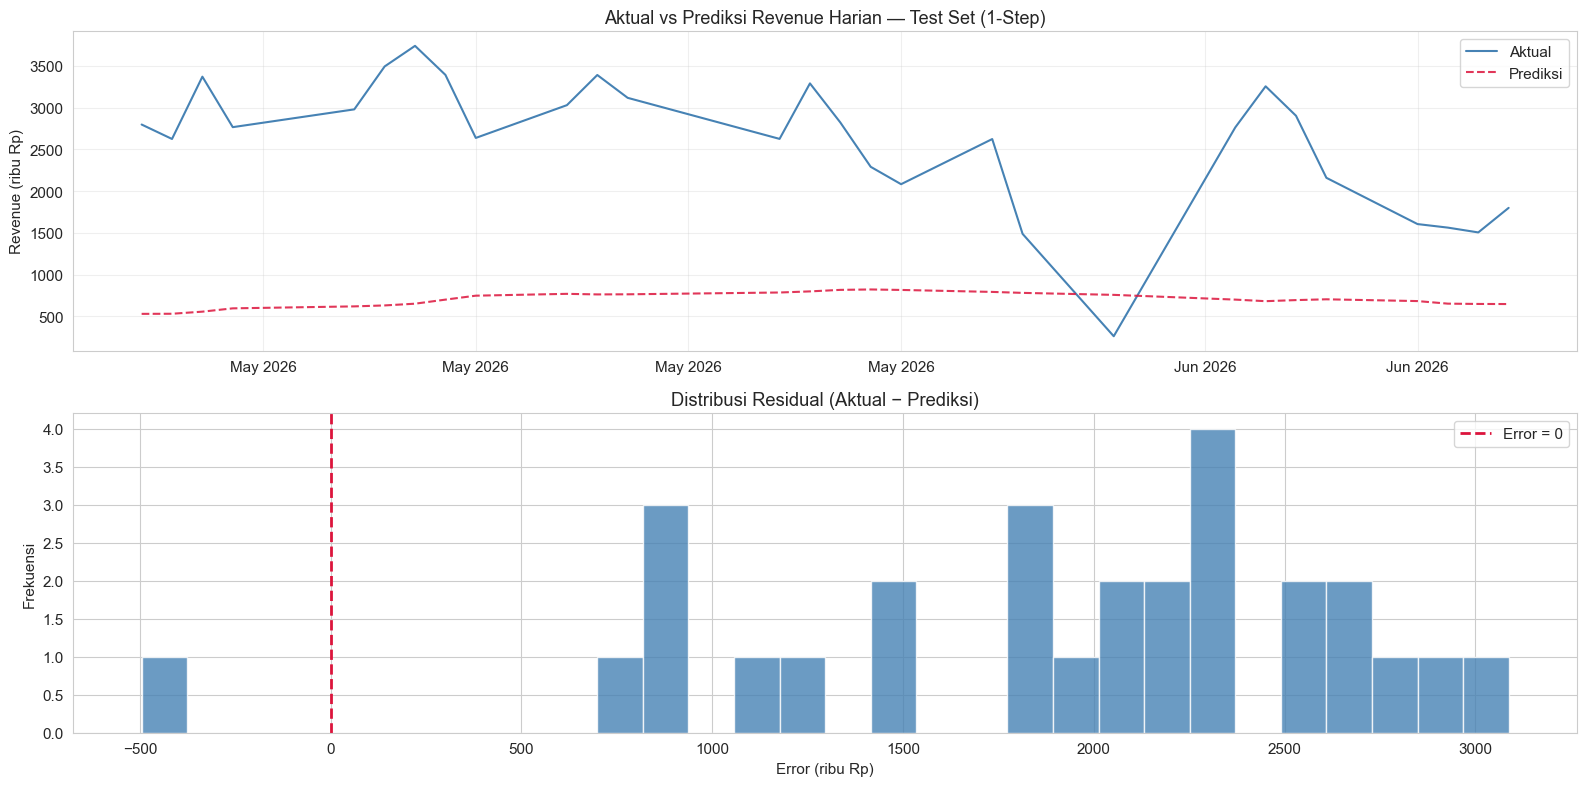

In [20]:
# 1-step-ahead dari setiap window → plot time series bersih
y_true_plot = res_test['y_true'][:, 0]
y_pred_plot = res_test['y_pred'][:, 0]

# Tanggal test: mulai setelah look_back dari batas test
start_idx = n_train + n_val + LOOK_BACK
end_idx   = start_idx + len(y_true_plot)
test_dates = df_active.iloc[start_idx:end_idx]['date'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# — Time series —
axes[0].plot(test_dates, y_true_plot/1e3, label='Aktual',   color='steelblue', linewidth=1.5)
axes[0].plot(test_dates, y_pred_plot/1e3, label='Prediksi', color='crimson',
             linewidth=1.5, linestyle='--', alpha=0.85)
axes[0].set_title('Aktual vs Prediksi Revenue Harian — Test Set (1-Step)', fontsize=13)
axes[0].set_ylabel('Revenue (ribu Rp)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# — Residual histogram —
residuals = y_true_plot - y_pred_plot
axes[1].hist(residuals/1e3, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=2, label='Error = 0')
axes[1].set_title('Distribusi Residual (Aktual − Prediksi)')
axes[1].set_xlabel('Error (ribu Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

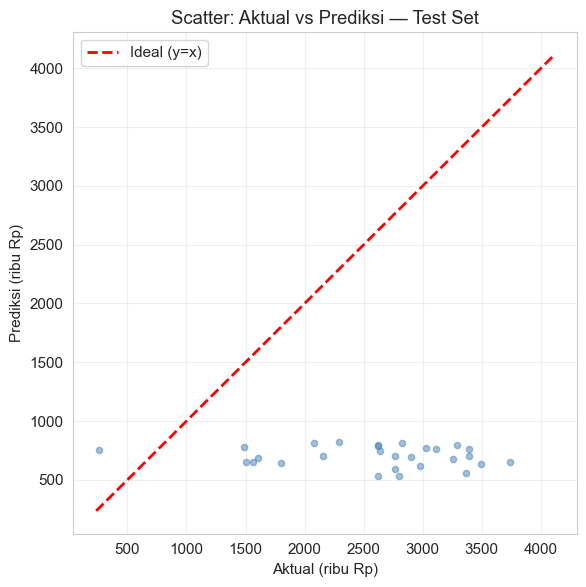

In [21]:
# Scatter: Actual vs Predicted
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true_plot/1e3, y_pred_plot/1e3, alpha=0.5, s=20, color='steelblue')
lo = min(y_true_plot.min(), y_pred_plot.min()) / 1e3 * 0.9
hi = max(y_true_plot.max(), y_pred_plot.max()) / 1e3 * 1.1
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal (y=x)')
ax.set_xlabel('Aktual (ribu Rp)')
ax.set_ylabel('Prediksi (ribu Rp)')
ax.set_title('Scatter: Aktual vs Prediksi — Test Set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 — Ringkasan Metrik Semua Model

In [22]:
# ── Evaluasi model mingguan ───────────────────────────────────────────────────
scaler_rev_w = MinMaxScaler()
scaler_rev_w.fit(weekly.iloc[:n_train_w][['revenue']].values)

print('=== Model Mingguan ===')
res_train_w = evaluate_model(model_weekly, X_train_w, y_train_w, scaler_rev_w, 'Train')
res_val_w   = evaluate_model(model_weekly, X_val_w,   y_val_w,   scaler_rev_w, 'Validation')
res_test_w  = evaluate_model(model_weekly, X_test_w,  y_test_w,  scaler_rev_w, 'Test')

# ── Evaluasi model bulanan (train/test only — tidak ada val) ─────────────────
scaler_rev_m = MinMaxScaler()
scaler_rev_m.fit(monthly.iloc[:n_train_m][['revenue']].values)

print('\n=== Model Bulanan (no-val) ===')
res_train_m = evaluate_model(model_monthly, X_train_m, y_train_m, scaler_rev_m, 'Train')
res_test_m  = evaluate_model(model_monthly, X_test_m,  y_test_m,  scaler_rev_m, 'Test')

# ── Tabel ringkasan ───────────────────────────────────────────────────────────
_keys = ['rmse','mae','mape']
summary = pd.DataFrame([
    {'Model': 'Harian',   'Set':'Train', **{k:v for k,v in res_train.items()   if k in _keys}},
    {'Model': 'Harian',   'Set':'Val',   **{k:v for k,v in res_val.items()     if k in _keys}},
    {'Model': 'Harian',   'Set':'Test',  **{k:v for k,v in res_test.items()    if k in _keys}},
    {'Model': 'Mingguan', 'Set':'Train', **{k:v for k,v in res_train_w.items() if k in _keys}},
    {'Model': 'Mingguan', 'Set':'Val',   **{k:v for k,v in res_val_w.items()   if k in _keys}},
    {'Model': 'Mingguan', 'Set':'Test',  **{k:v for k,v in res_test_w.items()  if k in _keys}},
    {'Model': 'Bulanan',  'Set':'Train', **{k:v for k,v in res_train_m.items() if k in _keys}},
    {'Model': 'Bulanan',  'Set':'Test',  **{k:v for k,v in res_test_m.items()  if k in _keys}},
])
summary['rmse'] = summary['rmse'].map('Rp {:,.0f}'.format)
summary['mae']  = summary['mae'].map('Rp {:,.0f}'.format)
summary['mape'] = summary['mape'].map('{:.2f}%'.format)
summary.columns = ['Model','Set','RMSE','MAE','MAPE']
print('\n=== RINGKASAN METRIK ===')
print(summary.to_string(index=False))

=== Model Mingguan ===
Train            RMSE: Rp    7,234,639  |  MAE: Rp    6,247,038  |  MAPE: 677.37%
Validation       RMSE: Rp    2,125,190  |  MAE: Rp    1,172,732  |  MAPE: 113.06%
Test             RMSE: Rp    8,438,925  |  MAE: Rp    7,822,939  |  MAPE:  89.28%

=== Model Bulanan (no-val) ===
Train            RMSE: Rp   13,132,824  |  MAE: Rp   10,864,483  |  MAPE: 59938.83%
Test             RMSE: Rp   19,110,917  |  MAE: Rp   17,731,207  |  MAPE: 132.19%

=== RINGKASAN METRIK ===
   Model   Set          RMSE           MAE      MAPE
  Harian Train  Rp 1,259,321  Rp 1,065,909   457.31%
  Harian   Val    Rp 736,224    Rp 612,369   584.22%
  Harian  Test  Rp 1,991,530  Rp 1,805,196    81.32%
Mingguan Train  Rp 7,234,639  Rp 6,247,038   677.37%
Mingguan   Val  Rp 2,125,190  Rp 1,172,732   113.06%
Mingguan  Test  Rp 8,438,925  Rp 7,822,939    89.28%
 Bulanan Train Rp 13,132,824 Rp 10,864,483 59938.83%
 Bulanan  Test Rp 19,110,917 Rp 17,731,207   132.19%


---
## SECTION 7 — Forecasting (Prediksi ke Depan)

### 7.1 — Prediksi 7 Hari Aktif ke Depan

In [23]:
def forecast_daily(model, df_active, scaler, scaler_rev, features, look_back, horizon):
    '''
    Forecast horizon hari aktif ke depan dari data terakhir.
    Returns: DataFrame dengan tanggal, hari, dan prediksi_revenue.
    '''
    last_data   = df_active.tail(look_back)[features].values
    last_scaled = scaler.transform(last_data)

    X_input = last_scaled.reshape(1, look_back, len(features))
    pred_scaled = model.predict(X_input, verbose=0)[0]  # (horizon,)

    # Inverse transform revenue
    pred_rev = scaler_rev.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()

    # Buat kalender prediksi: skip weekend & bulan libur (Jan/Jul)
    last_date = pd.Timestamp(df_active['date'].max())
    pred_dates = []
    d = last_date
    while len(pred_dates) < horizon:
        d += pd.Timedelta(days=1)
        if d.weekday() < 5 and d.month not in [1, 7]:
            pred_dates.append(d)

    return pd.DataFrame({
        'tanggal'          : [d.date() for d in pred_dates],
        'hari'             : [d.strftime('%A') for d in pred_dates],
        'prediksi_revenue' : np.round(pred_rev, 0).astype(int),
    })


forecast_d = forecast_daily(model_daily, df_active, scaler, scaler_rev,
                             FEATURES, LOOK_BACK, HORIZON)
print('=== Prediksi 7 Hari Aktif ke Depan ===')
print(forecast_d.to_string(index=False))
print(f'\nTotal prediksi  : Rp {forecast_d.prediksi_revenue.sum():,.0f}')
print(f'Rata-rata/hari  : Rp {forecast_d.prediksi_revenue.mean():,.0f}')

=== Prediksi 7 Hari Aktif ke Depan ===
   tanggal      hari  prediksi_revenue
2026-06-22    Monday            526919
2026-06-23   Tuesday            447324
2026-06-24 Wednesday            523254
2026-06-25  Thursday            902088
2026-06-26    Friday            213512
2026-06-29    Monday             45201
2026-06-30   Tuesday            660495

Total prediksi  : Rp 3,318,793
Rata-rata/hari  : Rp 474,113


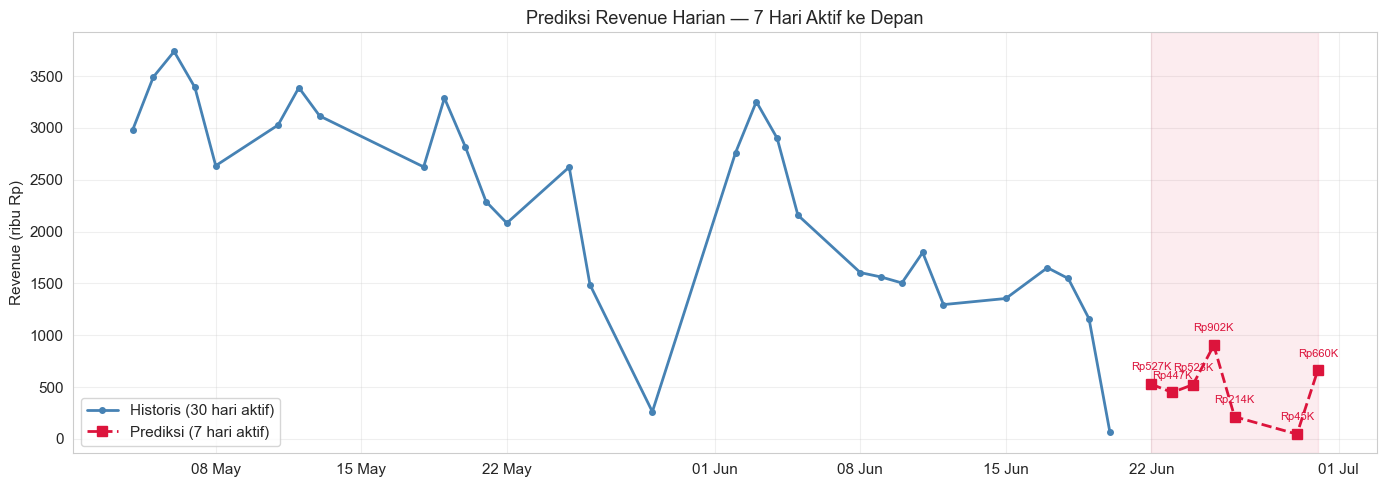

In [24]:
# Visualisasi: 30 hari historis + 7 hari prediksi
last_30 = df_active.tail(30)[['date','revenue']].copy()
last_30['date'] = pd.to_datetime(last_30['date'])
forecast_d['tanggal'] = pd.to_datetime(forecast_d['tanggal'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(last_30['date'], last_30['revenue']/1e3,
        'o-', color='steelblue', linewidth=2, markersize=4, label='Historis (30 hari aktif)')
ax.plot(forecast_d['tanggal'], forecast_d['prediksi_revenue']/1e3,
        's--', color='crimson', linewidth=2, markersize=7, label='Prediksi (7 hari aktif)')

# Anotasi nilai prediksi
for _, row in forecast_d.iterrows():
    ax.annotate(f'Rp{row.prediksi_revenue/1e3:.0f}K',
                xy=(row.tanggal, row.prediksi_revenue/1e3),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='crimson')

ax.axvspan(forecast_d['tanggal'].iloc[0], forecast_d['tanggal'].iloc[-1],
           alpha=0.08, color='crimson')
ax.set_title('Prediksi Revenue Harian — 7 Hari Aktif ke Depan', fontsize=13)
ax.set_ylabel('Revenue (ribu Rp)')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.show()

### 7.2 — Prediksi 4 Minggu ke Depan

In [25]:
def forecast_weekly_fn(model, weekly_df, scaler_w, features_w, look_back_w, horizon_w):
    last_data   = weekly_df.tail(look_back_w)[features_w].values
    last_scaled = scaler_w.transform(last_data)

    X_input = last_scaled.reshape(1, look_back_w, len(features_w))
    pred_scaled = model.predict(X_input, verbose=0)[0]

    # Inverse revenue (kolom 0): scale range dari scaler
    rev_min   = scaler_w.data_min_[0]
    rev_range = scaler_w.data_range_[0]
    pred_rev  = np.round(pred_scaled * rev_range + rev_min, 0).astype(int)

    last_week = pd.to_datetime(weekly_df['week_start'].max())
    return pd.DataFrame({
        'minggu_ke'        : range(1, horizon_w + 1),
        'week_start'       : [last_week + pd.Timedelta(weeks=i+1) for i in range(horizon_w)],
        'prediksi_revenue' : pred_rev,
    })


weekly_loaded = pd.read_csv(WEEKLY_CSV, parse_dates=['week_start'])
weekly_loaded = weekly_loaded[weekly_loaded['revenue'] > 0].sort_values('week_start').reset_index(drop=True)

forecast_w = forecast_weekly_fn(model_weekly, weekly_loaded, scaler_w,
                                 FEATURES_W, LOOK_BACK_W, HORIZON_W)
print('=== Prediksi 4 Minggu ke Depan ===')
print(forecast_w.to_string(index=False))
print(f'\nTotal prediksi : Rp {forecast_w.prediksi_revenue.sum():,.0f}')

=== Prediksi 4 Minggu ke Depan ===
 minggu_ke week_start  prediksi_revenue
         1 2026-06-22            446920
         2 2026-06-29           1828463
         3 2026-07-06            410785
         4 2026-07-13            459807

Total prediksi : Rp 3,145,975


### 7.3 — Prediksi 3 Bulan ke Depan

In [26]:
def forecast_monthly_fn(model, monthly_df, scaler_m, features_m, look_back_m, horizon_m):
    last_data   = monthly_df.tail(look_back_m)[features_m].values
    last_scaled = scaler_m.transform(last_data)

    X_input = last_scaled.reshape(1, look_back_m, len(features_m))
    pred_scaled = model.predict(X_input, verbose=0)[0]

    rev_min   = scaler_m.data_min_[0]
    rev_range = scaler_m.data_range_[0]
    pred_rev  = np.round(pred_scaled * rev_range + rev_min, 0).astype(int)

    last_year  = int(monthly_df['year'].max())
    last_month = int(monthly_df.loc[monthly_df['year'] == last_year, 'month'].max())
    months = []
    y, m = last_year, last_month
    for _ in range(horizon_m):
        m += 1
        if m > 12:
            m, y = 1, y + 1
        months.append(f'{y}-{m:02d}')

    return pd.DataFrame({
        'bulan_ke'         : range(1, horizon_m + 1),
        'year_month'       : months,
        'prediksi_revenue' : pred_rev,
    })


monthly_loaded = pd.read_csv(MONTHLY_CSV)
monthly_loaded = monthly_loaded[monthly_loaded['revenue'] > 0].sort_values(['year','month']).reset_index(drop=True)

forecast_m = forecast_monthly_fn(model_monthly, monthly_loaded, scaler_m,
                                  FEATURES_M, LOOK_BACK_M, HORIZON_M)
print('=== Prediksi 3 Bulan ke Depan ===')
print(forecast_m.to_string(index=False))
print(f'\nTotal prediksi : Rp {forecast_m.prediksi_revenue.sum():,.0f}')

=== Prediksi 3 Bulan ke Depan ===
 bulan_ke year_month  prediksi_revenue
        1    2026-07          18382418
        2    2026-08          14586837
        3    2026-09          21768790

Total prediksi : Rp 54,738,045


### 7.4 — Visualisasi Forecast Gabungan

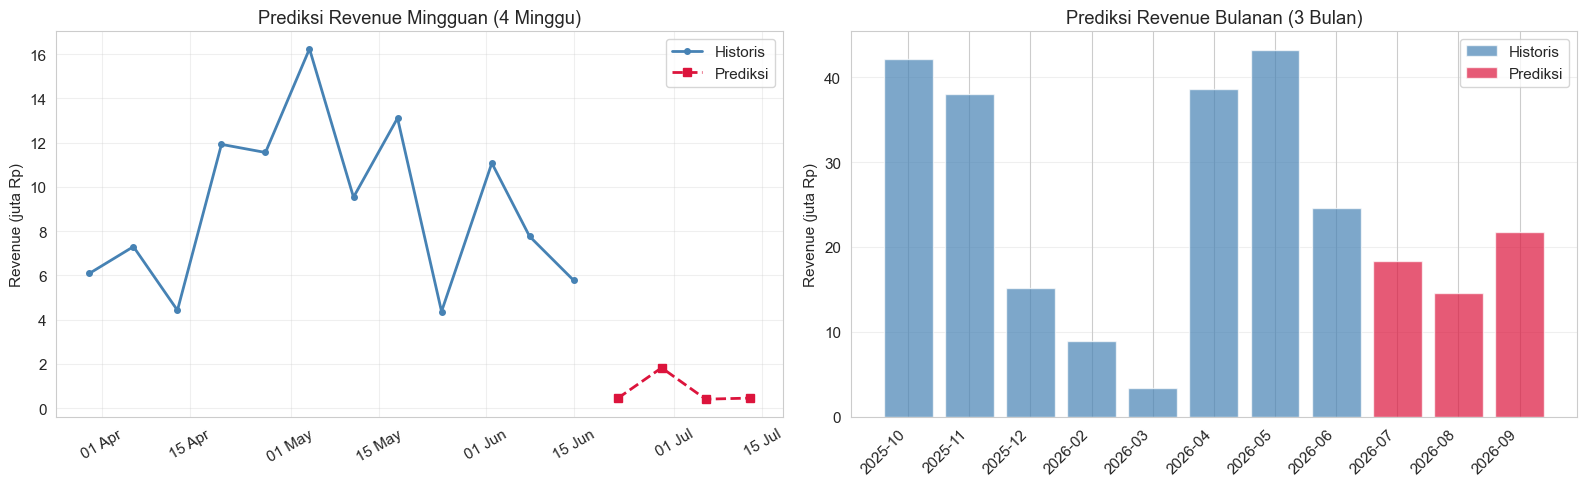

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Weekly forecast ───────────────────────────────────────────────────────────
ax = axes[0]
hist_w = weekly_loaded.tail(12)[['week_start','revenue']].copy()
ax.plot(hist_w['week_start'], hist_w['revenue']/1e6, 'o-',
        color='steelblue', linewidth=2, markersize=4, label='Historis')
ax.plot(forecast_w['week_start'], forecast_w['prediksi_revenue']/1e6, 's--',
        color='crimson', linewidth=2, markersize=6, label='Prediksi')
ax.set_title('Prediksi Revenue Mingguan (4 Minggu)')
ax.set_ylabel('Revenue (juta Rp)')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=30)

# ── Monthly forecast ──────────────────────────────────────────────────────────
ax = axes[1]
hist_m = monthly_loaded.tail(8).copy()
hist_m['label'] = hist_m['year'].astype(str) + '-' + hist_m['month'].astype(str).str.zfill(2)
x_h = range(len(hist_m))
x_f = range(len(hist_m), len(hist_m) + len(forecast_m))
ax.bar(x_h, hist_m['revenue']/1e6, color='steelblue', alpha=0.7, label='Historis')
ax.bar(x_f, forecast_m['prediksi_revenue']/1e6, color='crimson', alpha=0.7, label='Prediksi')
all_labels = list(hist_m['label']) + list(forecast_m['year_month'])
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right')
ax.set_title('Prediksi Revenue Bulanan (3 Bulan)')
ax.set_ylabel('Revenue (juta Rp)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()